# OTT Content Drop-off Analysis

## Episode-level engagement, content risk factors, data insights

### Мета цього проєкту: дослідити, які характеристики контенту пов'язані з підвищеним ризиком відпасти, визначити, на яких етапах перегляду метрика drop-off зростає та чому. Зробити висновки, корисні для прийняття рішень.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr
import statsmodels.formula.api as smf

df = pd.read_csv(r'C:\Users\hp\Desktop\проєктАналітика\ott_viewer_dropoff_retention_us_v1.0.csv')

df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,...,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,...,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,...,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,...,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,...,3,0,1,7,high,0,1,0.638,high,v1.0


In [98]:
print(f"Rows: {len(df)}")
print(f"Columns: {df.shape[1]}")
print(f"Unique shows: {df['show_id'].nunique()}")
print(f"Seasons: {df['season_number'].unique()}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Rows: 33171
Columns: 23
Unique shows: 489
Seasons: [1]
Missing values: 0
Duplicate rows: 0


In [99]:
df.dtypes

show_id                   int64
title                    object
platform                 object
genre                    object
release_year            float64
season_number             int64
episode_number            int64
episode_duration_min      int64
pacing_score              int64
hook_strength             int64
dialogue_density         object
visual_intensity          int64
avg_watch_percentage      int64
pause_count               int64
rewind_count              int64
skip_intro                int64
cognitive_load            int64
attention_required       object
night_watch_safe          int64
drop_off                  int64
drop_off_probability    float64
retention_risk           object
dataset_version          object
dtype: object

Dataset містить 33171 епізод, 489 унікальних show_id та 23 змінні.

Перевірка показала, що:
- пропущені значення відсутні;
- повні дублікати відсутні;
- усі записи належать до season_number = 1;
- 1 епізод = 1 рядочок

Тепер перейдемо до нашої метрики

In [100]:
df['drop_off'].value_counts()

drop_off
0    28367
1     4804
Name: count, dtype: int64

In [101]:
df['drop_off'].value_counts(normalize=True) * 100

drop_off
0    85.51747
1    14.48253
Name: proportion, dtype: float64

In [102]:
core_metrics = pd.DataFrame({
    "Metric": [
        "Episodes",
        "Shows",
        "Episode Drop-off Rate"
    ],
    "Value": [
        f"{len(df)}",
        f"{df['show_id'].nunique():,}",
        f"{df['drop_off'].mean() * 100:.2f}%"
    ]
})

display(core_metrics)

,Metric,Value
0,Episodes,33171
1,Shows,489
2,Episode Drop-off Rate,14.48%


Чи існують певні етапи епізодної послідовності, на яких drop_off помітно зростає?
Перевіримо такі питання:
- Чи спостерігається підвищений drop_off на ранніх епізодах?
- Можливо є просадка всередині епізодної послідовності?
- Чи відрізняються фінальні епізоди від інших?

In [103]:
episode_analysis = (
    df.groupby("episode_number")
      .agg(
          episodes=("drop_off", "size"),
          drop_off_rate=("drop_off", "mean")
      )
      .reset_index()
)

episode_analysis["drop_off_rate_pct"] = (
    episode_analysis["drop_off_rate"] * 100
)

first_10 = episode_analysis[
    episode_analysis["episode_number"] <= 10
]

display(first_10.round(2))

,episode_number,episodes,drop_off_rate,drop_off_rate_pct
0,1,500,0.04,3.60
1,2,497,0.18,17.91
2,3,492,0.14,14.02
3,4,487,0.16,16.22
4,5,484,0.15,15.50
5,6,479,0.17,16.70
6,7,456,0.17,16.89
7,8,445,0.18,18.20
8,9,395,0.15,14.68
9,10,378,0.15,15.34


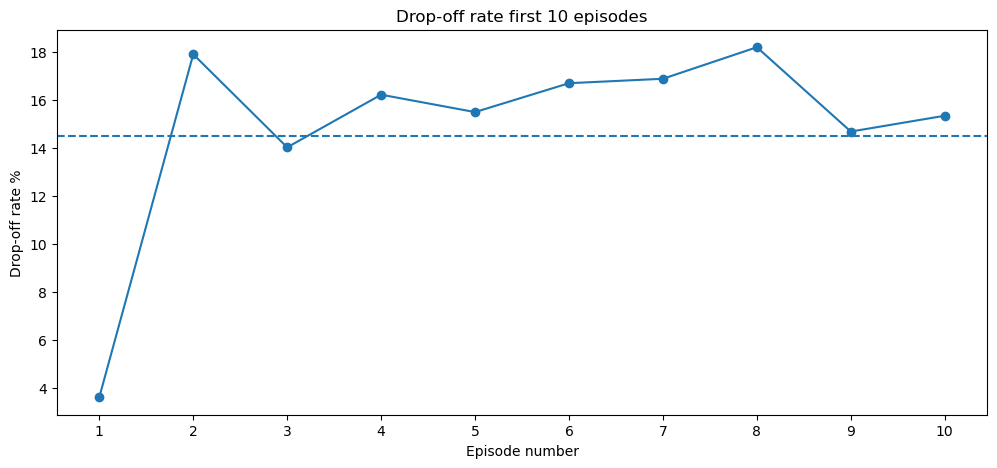

In [104]:
plt.figure(figsize=(12, 5))

plt.plot(
    first_10["episode_number"],
    first_10["drop_off_rate_pct"],
    marker="o"
)

plt.axhline(
    df["drop_off"].mean() * 100,
    linestyle="--"
)

plt.xlabel("Episode number")
plt.ylabel("Drop-off rate %")
plt.title("Drop-off rate first 10 episodes")
plt.xticks(range(1, 11))
plt.show()

Найбільша зміна на початку епізодної послідовності спостерігається між 1 та 2 епізодами, далі показник вже коливається навколо середнього рівня без іншого настільки ж вираженого стрибка, серед перших 10 епізодів.

Так як шоу мають в собі різну кількість епізодів, тому абсолютний episode_number не дозволяє коректно порівнювати пізні етапи різних епізодних послідовностей, тому для порівняння поділимо послідовність на чотири етапи:
- Beginning
- Early Middle
- Late Middle
- End

In [105]:
df = df.sort_values(
    ["show_id", "episode_number"]
).copy()
df["episode_rank"] = (
    df.groupby("show_id")["episode_number"]
      .rank(method="dense")
      .astype(int)
)
df["total_episodes"] = (
    df.groupby("show_id")["episode_number"]
      .transform("nunique")
)
df["relative_episode_position"] = (
    df["episode_rank"] / df["total_episodes"]
)
df["episode_stage"] = pd.cut(
    df["relative_episode_position"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["Beginning", "Early Middle", "Late Middle", "End"],
    include_lowest=True
)

stage_analysis = (
    df.groupby("episode_stage", observed=True)
      .agg(
          episodes=("drop_off", "size"),
          drop_off_rate=("drop_off", "mean")
      )
      .reset_index()
)

stage_analysis["drop_off_rate_pct"] = (
    stage_analysis["drop_off_rate"] * 100
)

display(
    stage_analysis[[
        "episode_stage",
        "episodes",
        "drop_off_rate_pct"
    ]].round(2)
)

,episode_stage,episodes,drop_off_rate_pct
0,Beginning,8141,14.00
1,Early Middle,8367,14.38
2,Late Middle,8204,14.57
3,End,8459,14.97


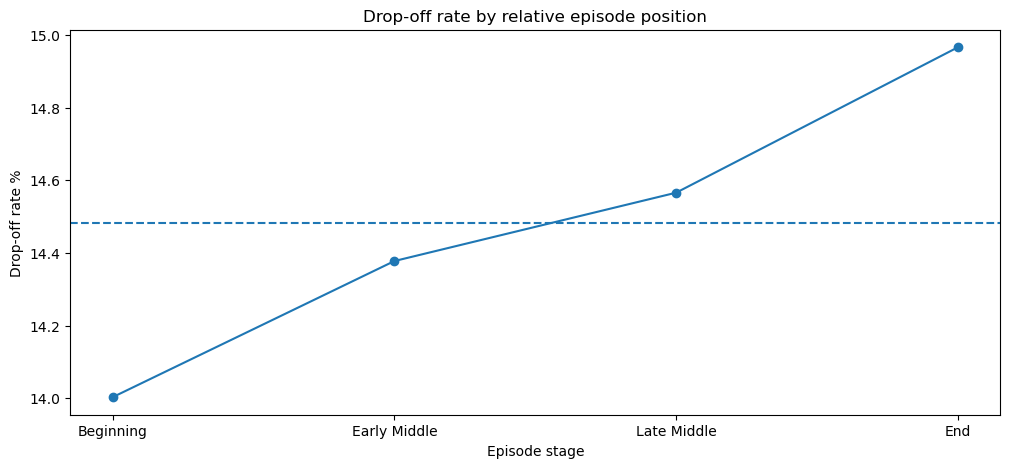

In [106]:
plt.figure(figsize=(12, 5))

plt.plot(
    stage_analysis["episode_stage"].astype(str),
    stage_analysis["drop_off_rate_pct"],
    marker="o"
)

plt.axhline(
    df["drop_off"].mean() * 100,
    linestyle="--"
)

plt.xlabel("Episode stage")
plt.ylabel("Drop-off rate %")
plt.title("Drop-off rate by relative episode position")
plt.show()

drop_off_rate показує поступовий зріст, проте різниця становить лише 0.97 п.п., тому можна припустити, що дані не демонструють сильного загального погіршення engagement у міру просування до кінця епізодної послідовності. Явної просадки всередині епізодної послідовності не виявлено.

In [107]:
df["is_final_episode"] = (
    df["episode_rank"] == df["total_episodes"]
)
finale_analysis = (
    df.groupby("is_final_episode")
      .agg(
          episodes=("drop_off", "size"),
          drop_off_rate=("drop_off", "mean")
      )
      .reset_index()
)

finale_analysis["episode_type"] = finale_analysis["is_final_episode"].map({
    False: "Non-final",
    True: "Final"
})

finale_analysis["drop_off_rate_pct"] = (
    finale_analysis["drop_off_rate"] * 100
)

display(
    finale_analysis[[
        "episode_type",
        "episodes",
        "drop_off_rate_pct"
    ]].round(2)
)

finale_table = pd.crosstab(
    df["is_final_episode"],
    df["drop_off"]
)

chi2, p_value, dof, expected = chi2_contingency(finale_table)

n = finale_table.to_numpy().sum()

cramers_v = np.sqrt(chi2 / n)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

,episode_type,episodes,drop_off_rate_pct
0,Non-final,32671,14.43
1,Final,500,17.60


Chi-square: 3.732
p-value: 0.0534
Cramer's V: 0.011


Бачимо, що фінальні епізоди мають вищий drop_off_rate, порівняно з іншими, однак Chi-square test не досягає стандартного рівня статистичної значущості, до того ж коефцієнт Крамера показує слабку силу зв'язку. Тому дані не дають достатніх підстав стверджувати, що фінальні епізоди систематично пов'язані з підвищеним drop_off.

In [108]:
df.describe()

,show_id,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,night_watch_safe,drop_off,drop_off_probability,episode_rank,total_episodes,relative_episode_position
count,33171.000000,33171.000000,33171.0,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000
mean,63698.539688,2000.739743,1.0,423.718881,37.660667,5.397908,5.525158,6.009436,56.805764,3.102921,2.003497,0.493262,6.196015,0.015887,0.144825,0.478433,423.523590,846.047180,0.507537
std,65206.256887,15.750470,0.0,557.688460,22.899741,1.230418,1.730098,1.994370,12.577000,1.866938,1.548391,0.499962,1.322146,0.125042,0.351930,0.107382,557.775804,868.554801,0.288935
min,36.000000,1952.000000,1.0,1.000000,1.000000,3.000000,3.000000,3.000000,13.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.120000,1.000000,1.000000,0.000377
25%,15226.000000,1992.000000,1.0,27.000000,24.000000,4.000000,4.000000,4.000000,48.000000,2.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.400000,26.000000,99.000000,0.256184
50%,35024.000000,2004.000000,1.0,178.000000,33.000000,5.000000,6.000000,6.000000,57.000000,3.000000,2.000000,0.000000,7.000000,0.000000,0.000000,0.471000,178.000000,629.000000,0.503774
75%,80885.000000,2012.000000,1.0,611.000000,49.000000,6.000000,7.000000,8.000000,66.000000,4.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.553000,611.000000,1186.000000,0.756789
max,305062.000000,2025.000000,1.0,2650.000000,1225.000000,8.000000,10.000000,9.000000,100.000000,10.000000,8.000000,1.000000,9.000000,1.000000,1.000000,0.831000,2650.000000,2650.000000,1.000000


Чи пов'язана тривалість епізоду з вищим drop_off?

In [109]:
duration_bins = [0, 30, 45, 60, 90, np.inf]
duration_labels = ["<30", "30–45", "45–60", "60–90", "90+"]

df["duration_group"] = pd.cut(
    df["episode_duration_min"],
    bins=duration_bins,
    labels=duration_labels,
    right=False
)

duration_analysis = (
    df.groupby("duration_group", observed=True)
      .agg(
          episodes=("drop_off", "size"),
          drop_off_rate=("drop_off", "mean"),
          avg_watch_percentage=("avg_watch_percentage", "mean")
      )
      .reset_index()
)

duration_analysis["drop_off_rate_pct"] = (
    duration_analysis["drop_off_rate"] * 100
)

display(
    duration_analysis[[
        "duration_group",
        "episodes",
        "drop_off_rate_pct",
        "avg_watch_percentage"
    ]].round(2)
)

,duration_group,episodes,drop_off_rate_pct,avg_watch_percentage
0,<30,15498,13.66,57.13
1,30–45,7020,15.74,56.00
2,45–60,5989,16.73,56.12
3,60–90,3977,12.75,57.83
4,90+,687,10.63,57.92


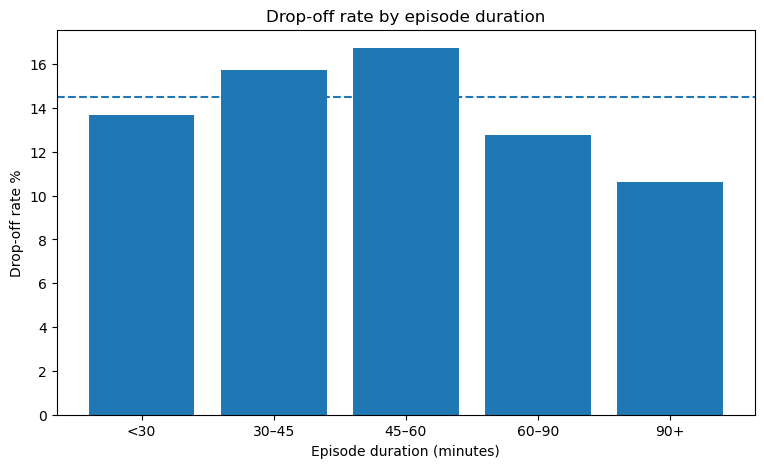

In [110]:
plt.figure(figsize=(9, 5))

plt.bar(
    duration_analysis["duration_group"].astype(str),
    duration_analysis["drop_off_rate_pct"]
)

plt.axhline(
    df["drop_off"].mean() * 100,
    linestyle="--"
)

plt.xlabel("Episode duration (minutes)")
plt.ylabel("Drop-off rate %")
plt.title("Drop-off rate by episode duration")
plt.show()

Найвищий drop_off_rate спостерігається для епізодів тривалістю 45–60 хвилин, тоді як для груп 60 - 90 та 90+ хвилин показник нижчий. Тож, дані не підтримують просту гіпотезу, що чим довший епізод, тим вищий drop-off. Тепер перевіримо, чи відрізняється drop_off_rate між жанрами:

In [111]:
genre_counts = (
    df["genre"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["genre", "episodes"]

display(genre_counts)

,genre,episodes
0,Animation,10028
1,Drama,6142
2,Action & Adventure,4705
3,Reality,4005
4,Comedy,3067
5,Talk,2074
6,Crime,926
7,Kids,632
8,Sci-Fi & Fantasy,574
9,Soap,334


In [112]:
large_genres = genre_counts[
    genre_counts["episodes"] >= 100
]["genre"]

genre_df = df[df["genre"].isin(large_genres)]

In [113]:
genre_analysis = (
    genre_df.groupby("genre")
    .agg(
        episodes=("drop_off", "count"),
        drop_off_rate=("drop_off", "mean"),
        avg_watch_percentage=("avg_watch_percentage", "mean")
    )
    .reset_index()
)

genre_analysis["drop_off_rate_pct"] = (
    genre_analysis["drop_off_rate"] * 100
)

genre_analysis = genre_analysis.sort_values(
    "drop_off_rate_pct",
    ascending=False
)

display(
    genre_analysis[[
        "genre",
        "episodes",
        "drop_off_rate_pct",
        "avg_watch_percentage"
    ]].round(2)
)

,genre,episodes,drop_off_rate_pct,avg_watch_percentage
4,Drama,6142,24.19,52.11
7,Mystery,233,18.88,54.12
3,Crime,926,15.87,57.22
8,Reality,4005,13.56,56.88
1,Animation,10028,13.48,57.11
10,Soap,334,13.17,57.23
11,Talk,2074,13.16,57.23
9,Sci-Fi & Fantasy,574,13.07,57.43
0,Action & Adventure,4705,13.05,57.11
5,Family,208,12.98,56.71


In [114]:
genre_table = pd.crosstab(
    df["genre"],
    df["drop_off"]
)

chi2, p_value, dof, expected = chi2_contingency(genre_table)

n = genre_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(genre_table.shape[0] - 1,
                    genre_table.shape[1] - 1))
)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p_value:.4g}")
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square: 838.843
p-value: 4.26e-169
Cramer's V: 0.159


drop_off_rate помітно відрізняється між жанрами - серед жанрів з достатньою кількістю спостережень, Drama має найвищий показник, тоді як Comedy - найнижчий.
Chi-square test підтверджує статистичну значущість між genre та drop_off (p < 0.001). Водночас Cramer's V = 0.159 вказує, що сила зв'язку є відносно невеликою. Так само проаналізуємо платформи:

In [115]:
platform_analysis = (
    df.groupby("platform")
    .agg(
        episodes=("drop_off", "count"),
        drop_off_rate=("drop_off", "mean"),
        avg_watch_percentage=("avg_watch_percentage", "mean")
    )
    .reset_index()
)

platform_analysis["drop_off_rate_pct"] = (
    platform_analysis["drop_off_rate"] * 100
)

platform_analysis = platform_analysis.sort_values(
    "drop_off_rate_pct",
    ascending=False
)

display(
    platform_analysis[[
        "platform",
        "episodes",
        "drop_off_rate_pct",
        "avg_watch_percentage"
    ]].round(2)
)

,platform,episodes,drop_off_rate_pct,avg_watch_percentage
9,Kocowa,27,22.22,56.19
3,Britbox Apple TV Channel,167,21.56,55.59
2,Apple TV,70,21.43,54.49
16,Paramount Plus Apple TV Channel,311,20.58,53.91
22,Shahid VIP,40,20.00,51.60
24,Starz Apple TV Channel,10,20.00,49.10
17,Paramount+ Amazon Channel,30,20.00,55.27
23,Spectrum On Demand,48,18.75,52.21
15,PBS Documentaries Amazon Channel,27,18.52,56.22
5,Disney+,2467,16.94,55.89


In [116]:
large_platforms = platform_analysis[
    platform_analysis["episodes"] >= 100
]["platform"]

platform_df = df[
    df["platform"].isin(large_platforms)
]

platform_table = pd.crosstab(
    platform_df["platform"],
    platform_df["drop_off"]
)

chi2, p_value, dof, expected = chi2_contingency(platform_table)

n = platform_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / n)

print(f"Platforms included: {platform_df['platform'].nunique()}")
print(f"Episodes included: {len(platform_df):,}")
print(f"Chi-square: {chi2:.3f}")
print("p-value: < 0.001" if p_value < 0.001 else f"p-value: {p_value:.4f}")
print(f"Cramer's V: {cramers_v:.3f}")

Platforms included: 14
Episodes included: 32,743
Chi-square: 163.238
p-value: < 0.001
Cramer's V: 0.071


drop_off_rate також відрізняється і між платформами, і Chi-square test показує статистичну значимість. Коефіцієнт Крамера говорить про слабку силу зв'язку, отже platform має менший зв'язок із drop_off, ніж жанри.

In [117]:
dropoff_comparison = (
    df.groupby("drop_off")
    .agg(
        episodes=("drop_off", "size"),
        avg_watch_percentage=("avg_watch_percentage", "mean"),
        avg_duration_min=("episode_duration_min", "mean"),
        avg_pacing=("pacing_score", "mean"),
        avg_hook_strength=("hook_strength", "mean"),
        avg_cognitive_load=("cognitive_load", "mean"),
        avg_pause_count=("pause_count", "mean"),
        avg_rewind_count=("rewind_count", "mean"),
        avg_visual_intensity=("visual_intensity", "mean")
    )
    .reset_index()
    .round(2)
)

display(dropoff_comparison)

,drop_off,episodes,avg_watch_percentage,avg_duration_min,avg_pacing,avg_hook_strength,avg_cognitive_load,avg_pause_count,avg_rewind_count,avg_visual_intensity
0,0,28367,60.15,37.66,5.61,5.74,5.89,2.86,2.00,6.01
1,1,4804,37.08,37.66,4.16,4.24,8.03,4.52,2.01,6.02


Датасет містить кілька категоріальних змінних, перевіримо спочатку їх, наскільки сильно dialogue_density, attention_required, skip_intro та night_watch_safe взагалі мають відношення до drop_off, а потім будемо працювати з сильними показниками таблиці вище.

In [118]:
categorical_features = [
    "dialogue_density",
    "attention_required",
    "skip_intro",
    "night_watch_safe"
]

for feature in categorical_features:
    
    analysis = (
        df.groupby(feature)
        .agg(
            episodes=("drop_off", "count"),
            drop_off_rate=("drop_off", "mean"),
            avg_watch_percentage=("avg_watch_percentage", "mean")
        )
        .reset_index()
    )
    
    analysis["drop_off_rate_pct"] = (
        analysis["drop_off_rate"] * 100
    )
    
    print(f"\n{feature}")
    
    display(
        analysis[[
            feature,
            "episodes",
            "drop_off_rate_pct",
            "avg_watch_percentage"
        ]].round(2)
    )


dialogue_density


,dialogue_density,episodes,drop_off_rate_pct,avg_watch_percentage
0,high,11115,30.36,50.15
1,low,11115,6.28,60.12
2,medium,10941,6.68,60.20



attention_required


,attention_required,episodes,drop_off_rate_pct,avg_watch_percentage
0,high,16878,28.46,49.15
1,medium,16293,0.00,64.74



skip_intro


,skip_intro,episodes,drop_off_rate_pct,avg_watch_percentage
0,0,16809,5.9,62.80
1,1,16362,23.3,50.65



night_watch_safe


,night_watch_safe,episodes,drop_off_rate_pct,avg_watch_percentage
0,0,32644,14.72,56.50
1,1,527,0.00,75.74


In [119]:
categorical_results = []

for feature in categorical_features:
    
    table = pd.crosstab(
        df[feature],
        df["drop_off"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    n = table.to_numpy().sum()
    
    cramers_v = np.sqrt(
        chi2 / (
            n * min(
                table.shape[0] - 1,
                table.shape[1] - 1
            )
        )
    )
    
    categorical_results.append({
        "feature": feature,
        "chi_square": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v,
    })

categorical_results = pd.DataFrame(categorical_results)

display(
    categorical_results.round(4)
)

,feature,chi_square,p_value,cramers_v
0,dialogue_density,3405.1426,0.0,0.3204
1,attention_required,5420.5600,0.0,0.4042
2,skip_intro,2027.3769,0.0,0.2472
3,night_watch_safe,89.5048,0.0,0.0519


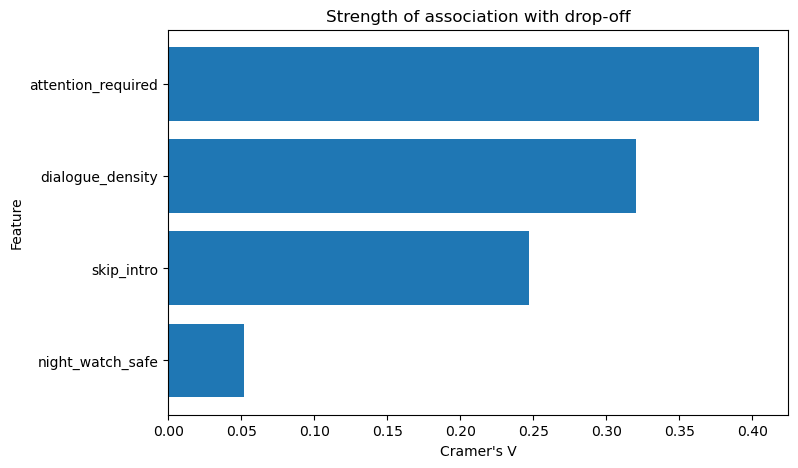

In [120]:
categorical_results = categorical_results.sort_values(
    "cramers_v",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    categorical_results["feature"],
    categorical_results["cramers_v"]
)

plt.xlabel("Cramer's V")
plt.ylabel("Feature")
plt.title("Strength of association with drop-off")
plt.show()

Серед цих змінних найсильнішим зв'язком виявилася з attention_required, далі dialogue_density, skip_intro, night_watch_safe. Усі статистичні тести мають p < 0.001, але величина сили зв'язку між ними суттєво відрізняється. attention_required та dialogue_density це те, що формує характеристики контенту, які теоретично і є причиною відтоку, тому скоріше перейдемо до їх аналізу. 

Ми вже бачили, що епізоди з drop_off = 1 у середньому мають нижчі hook_strength та pacing_score, але вищі cognitive_load і pause_count, водночас середні episode_duration_min, rewind_count та visual_intensity майже не відрізняються між двома групами. Це робить hook_strength, pacing_score та cognitive_load основними ознаками контенту для подальшого аналізу. pause_count розглянемо окремо як критичний поведінковий сигнал, який важливо відслідковувати.

In [121]:
def analyze_feature(feature):
    
    result = (
        df.groupby(feature)
        .agg(
            episodes=("drop_off", "count"),
            drop_off_rate=("drop_off", "mean"),
            avg_watch_percentage=("avg_watch_percentage", "mean")
        )
        .reset_index()
    )
    
    result["drop_off_rate_pct"] = (
        result["drop_off_rate"] * 100
    )
    
    return result

In [122]:
hook_analysis = analyze_feature("hook_strength")
pacing_analysis = analyze_feature("pacing_score")
cognitive_analysis = analyze_feature("cognitive_load")

print("Hook strength")
display(hook_analysis.round(2))

print("Pacing score")
display(pacing_analysis.round(2))

print("Cognitive load")
display(cognitive_analysis.round(2))

Hook strength


,hook_strength,episodes,drop_off_rate,avg_watch_percentage,drop_off_rate_pct
0,3,5515,0.37,46.66,37.12
1,4,5430,0.21,50.80,20.59
2,5,5484,0.12,54.57,11.91
3,6,5606,0.09,58.66,9.24
4,7,5423,0.06,62.74,6.23
5,8,5527,0.02,66.83,2.35
6,9,83,0.00,70.40,0.00
7,10,103,0.00,73.54,0.00


Pacing score


,pacing_score,episodes,drop_off_rate,avg_watch_percentage,drop_off_rate_pct
0,3,1550,0.48,42.24,47.81
1,4,7562,0.42,45.15,41.70
2,5,8340,0.05,58.25,5.44
3,6,8358,0.04,61.39,3.72
4,7,6580,0.02,64.10,2.20
5,8,781,0.00,72.63,0.00


Cognitive load


,cognitive_load,episodes,drop_off_rate,avg_watch_percentage,drop_off_rate_pct
0,4,527,0.00,75.74,0.00
1,5,15512,0.00,64.34,0.00
2,6,254,0.00,66.19,0.00
3,7,13783,0.17,51.63,16.97
4,9,3095,0.80,38.10,79.64


Уважно проаналізуємо ці таблички: зі зростанням hook_strength спостерігається чітке зниження drop_off_rate, тобто результат вказує на сильний негативний зв'язок між ними. Низькі значення pacing_score асоційовані зі значно вищим drop_off_rate. Особливо різкий перехід спостерігається між pacing_score = 4 і 5. І на останок - вищий cognitive_load відповідає різкому зростанню метрики - теоретично найвпливовіший показник з цих 3. Також, дивлячись на таблиці, стає видно синтетичність самого датасету. Проте, ми все ж побачили ці патерни, перевіримо статистичну значущість:

In [123]:
features = [
    "hook_strength",
    "pacing_score",
    "cognitive_load"
]

spearman_results = []

for feature in features:
    
    correlation, p_value = spearmanr(
        df[feature],
        df["drop_off"]
    )
    
    spearman_results.append({
        "feature": feature,
        "spearman_rho": correlation,
        "p_value": p_value
    })

spearman_results = pd.DataFrame(spearman_results)

display(spearman_results.round(4))

,feature,spearman_rho,p_value
0,hook_strength,-0.3051,0.0
1,pacing_score,-0.4163,0.0
2,cognitive_load,0.5171,0.0


Кореляція Спірмана показує статистичну значущість для всіх 3 показників.

Усі три content characteristics статистично значущо асоційовані з drop_off (p < 0.001). Найсильніший зв'язок спостерігається для cognitive_load, далі - pacing_score та hook_strength. Знакки кореляції також відповідають нашому аналізу до цього: вищі hook і pacing пов'язані з нижчим drop-off, тоді як вищий cognitive load - з вищим drop-off. Перевіримо чи є статистично значуща різниця між drop_off 0 і 1 для цих показників:

In [124]:
mw_results = []

for feature in features:
    
    group_0 = df[df["drop_off"] == 0][feature]
    group_1 = df[df["drop_off"] == 1][feature]
    
    u_stat, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    rbc = 1 - (2 * u_stat) / (len(group_0) * len(group_1))
    
    mw_results.append({
        "feature": feature,
        "U_statistic": u_stat,
        "p_value": p_value,
        "rank_biserial": rbc
    })

mw_results = pd.DataFrame(mw_results)

display(mw_results.round(4))

,feature,U_statistic,p_value,rank_biserial
0,hook_strength,101775634.5,0.0,-0.4937
1,pacing_score,113454589.0,0.0,-0.6651
2,cognitive_load,15633803.0,0.0,0.7706


U тест показав статистично значущі відмінності між drop_off = 0 та 1 (p < 0.001). Найбільша різниця спостерігається для cognitive_load, потім для pacing_score та hook_strength.
Але на відміну від цих показників, pause_count більше описує поведінку користувача, а не безпосередню характеристику контенту, саме час розглянути його:

In [125]:
rho, spearman_p = spearmanr(
    df["pause_count"],
    df["drop_off"]
)

group_0 = df[df["drop_off"] == 0]["pause_count"]
group_1 = df[df["drop_off"] == 1]["pause_count"]

u_stat, mw_p = mannwhitneyu(
    group_0,
    group_1,
    alternative="two-sided"
)

rbc = 1 - (
    2 * u_stat / (len(group_0) * len(group_1))
)

print(f"Spearman rho: {rho:.3f}")
print("Spearman p-value: < 0.001" if spearman_p < 0.001 else f"Spearman p-value: {spearman_p:.4f}")

print(f"Mann-Whitney U: {u_stat:.1f}")
print("Mann-Whitney p-value: < 0.001" if mw_p < 0.001 else f"Mann-Whitney p-value: {mw_p:.4f}")

print(f"Rank-biserial correlation: {rbc:.3f}")

Spearman rho: 0.289
Spearman p-value: < 0.001
Mann-Whitney U: 36341905.0
Mann-Whitney p-value: < 0.001
Rank-biserial correlation: 0.467


Вищий pause_count пов'язаний з вищою ймовірністю drop-off. З цим закінчили, тепер давайте визначимо чи перетинаються ключові характеристики контенту та поведінки юзера між собою?

In [126]:
analysis_features = [
    "hook_strength",
    "pacing_score",
    "cognitive_load",
    "pause_count"
]

feature_corr = (
    df[analysis_features]
    .corr(method="spearman")
    .round(3)
)

display(feature_corr)

,hook_strength,pacing_score,cognitive_load,pause_count
hook_strength,1.000,-0.001,-0.001,-0.002
pacing_score,-0.001,1.000,-0.558,-0.186
cognitive_load,-0.001,-0.558,1.000,0.328
pause_count,-0.002,-0.186,0.328,1.000


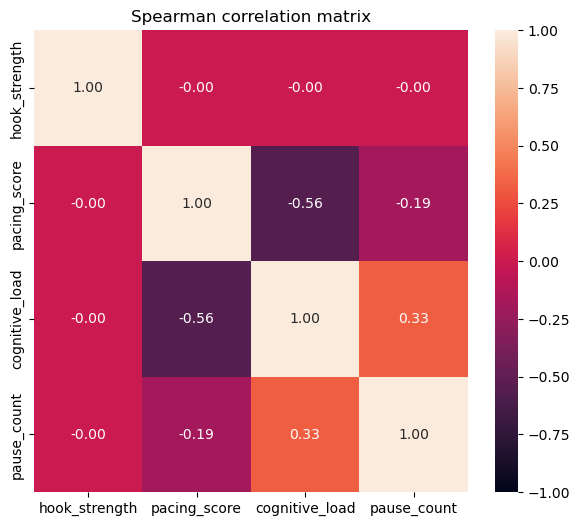

In [127]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Spearman correlation matrix")
plt.show()

Найпомітніший зв'язок спостерігається між pacing_score та cognitive_load (ρ = -0.558): вищий pacing в датасеті часто поєднується з нижчим cognitive load.
cognitive_load також має помірну позитивну кореляцію з pause_count, тоді як зв'язок між pacing_score та pause_count слабший (ρ = -0.186).
А hook_strength практично не корелює з іншими змінними.

Перевіримо тепер що відбувається, коли кілька несприятливих характеристик зустрічаються одночасно, чи збільшується наша метрика, чи ні?
Епізод вважається high-risk лише тоді, коли виконує всі три умови одночасно:
- hook_strength <= 4
- pacing_score <= 4
- cognitive_load >= 7

In [128]:
df["weak_hook"] = df["hook_strength"] <= 4
df["slow_pacing"] = df["pacing_score"] <= 4
df["high_cognitive_load"] = df["cognitive_load"] >= 7

df["high_content_risk"] = (
    df["weak_hook"]
    & df["slow_pacing"]
    & df["high_cognitive_load"]
)

In [129]:
risk_comparison = (
    df.groupby("high_content_risk")
    .agg(
        episodes=("drop_off", "size"),
        drop_off_rate=("drop_off", "mean")
    )
    .reset_index()
)

risk_comparison["episode_share_pct"] = (
    risk_comparison["episodes"] / len(df) * 100
)

risk_comparison["drop_off_rate_pct"] = (
    risk_comparison["drop_off_rate"] * 100
)

display(
    risk_comparison[[
        "high_content_risk",
        "episodes",
        "episode_share_pct",
        "drop_off_rate_pct",
    ]].round(2)
)

,high_content_risk,episodes,episode_share_pct,drop_off_rate_pct
0,False,30194,91.03,8.35
1,True,2977,8.97,76.72


High-risk комбінація охоплює лише 8.97% епізодів, але має drop_off_rate 76.72% порівняно з 8.35% серед інших епізодів. Це свідчить про те, що комбінація weak hook, slow pacing та high cognitive load є значно сильнішою комбінацією, ніж розгляд цих характеристик окремо.

Логічне питання: у яких genres та platforms частіше зустрічаються епізоди з визначеним high-risk content profile? Для кожної групи розрахуємо частку епізодів, які одночасно мають ці 3 компоненти.

In [130]:
genre_risk = (
    df.groupby("genre")
    .agg(
        episodes=("drop_off", "size"),
        high_risk_episodes=("high_content_risk", "sum"),
        high_risk_share=("high_content_risk", "mean"),
        drop_off_rate=("drop_off", "mean")
    )
    .reset_index()
)

genre_risk["high_risk_share_pct"] = (
    genre_risk["high_risk_share"] * 100
)

genre_risk["drop_off_rate_pct"] = (
    genre_risk["drop_off_rate"] * 100
)

genre_risk = genre_risk.sort_values(
    "high_risk_share_pct",
    ascending=False
)

display(
    genre_risk[[
        "genre",
        "episodes",
        "high_risk_episodes",
        "high_risk_share_pct",
        "drop_off_rate_pct"
    ]].round(2)
)

,genre,episodes,high_risk_episodes,high_risk_share_pct,drop_off_rate_pct
5,Drama,6142,984,16.02,24.19
4,Documentary,75,10,13.33,17.33
8,Mystery,233,28,12.02,18.88
3,Crime,926,99,10.69,15.87
14,War & Politics,51,5,9.80,15.69
11,Sci-Fi & Fantasy,574,56,9.76,13.07
6,Family,208,19,9.13,12.98
7,Kids,632,55,8.70,11.87
0,Action & Adventure,4705,397,8.44,13.05
1,Animation,10028,821,8.19,13.48


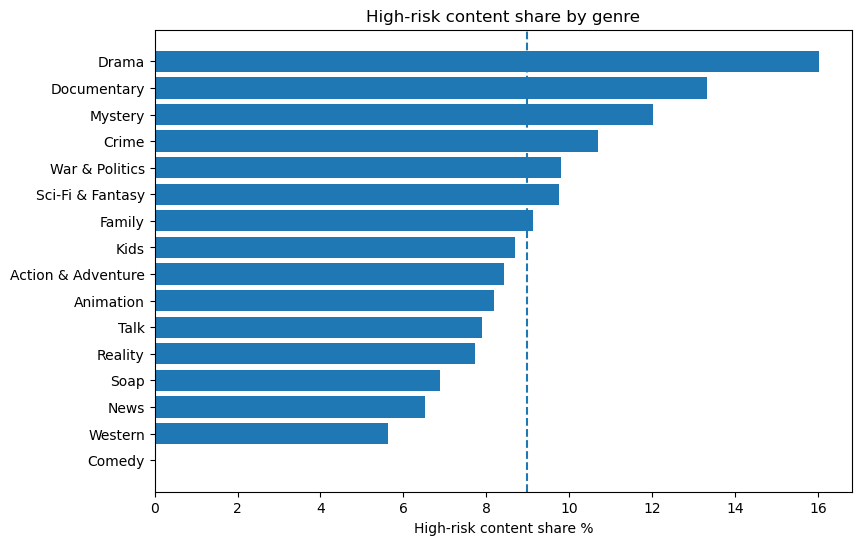

In [131]:
genre_risk_plot = genre_risk.sort_values(
    "high_risk_share_pct",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    genre_risk_plot["genre"],
    genre_risk_plot["high_risk_share_pct"]
)

plt.axvline(
    df["high_content_risk"].mean() * 100,
    linestyle="--"
)

plt.xlabel("High-risk content share %")
plt.ylabel("")
plt.title("High-risk content share by genre")
plt.show()

In [132]:
platform_risk = (
    df.groupby("platform")
    .agg(
        episodes=("drop_off", "size"),
        high_risk_episodes=("high_content_risk", "sum"),
        high_risk_share=("high_content_risk", "mean"),
        drop_off_rate=("drop_off", "mean")
    )
    .reset_index()
)

platform_risk["high_risk_share_pct"] = (
    platform_risk["high_risk_share"] * 100
)

platform_risk["drop_off_rate_pct"] = (
    platform_risk["drop_off_rate"] * 100
)

platform_risk_filtered = (
    platform_risk[
        platform_risk["episodes"] >= 100
    ]
    .sort_values(
        "high_risk_share_pct",
        ascending=False
    )
)

display(
    platform_risk_filtered[[
        "platform",
        "episodes",
        "high_risk_episodes",
        "high_risk_share_pct",
        "drop_off_rate_pct"
    ]].round(2)
)

,platform,episodes,high_risk_episodes,high_risk_share_pct,drop_off_rate_pct
16,Paramount Plus Apple TV Channel,311,45,14.47,20.58
8,Hulu,7967,862,10.82,16.53
3,Britbox Apple TV Channel,167,17,10.18,21.56
5,Disney+,2467,251,10.17,16.94
20,Prime Video,2693,261,9.69,14.63
4,Crunchyroll,446,39,8.74,14.57
13,Netflix,12270,1057,8.61,13.94
14,OnDemandKorea,1582,125,7.90,12.45
10,Kocowa Amazon Channel,2245,173,7.71,14.25
18,Peacock Premium,686,46,6.71,11.37


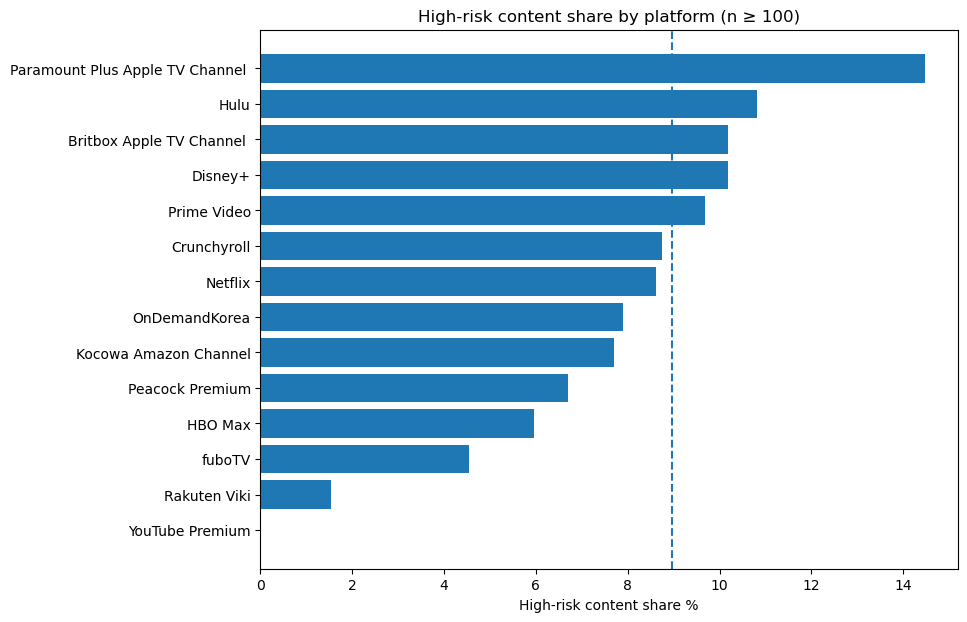

In [133]:
platform_risk_plot = platform_risk_filtered.sort_values(
    "high_risk_share_pct",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    platform_risk_plot["platform"],
    platform_risk_plot["high_risk_share_pct"]
)

plt.axvline(
    df["high_content_risk"].mean() * 100,
    linestyle="--"
)

plt.xlabel("High-risk content share %")
plt.ylabel("")
plt.title("High-risk content share by platform (n ≥ 100)")
plt.show()

Що ми тут бачимо - розподіл між жанрами нерівномірний, найбільша концентрація high-risk епізодів спостерігається у Drama і суттєво перевищує середнє значення. Водночас Comedy не містить таких епізодів та має низький drop_off_rate. Це може пояснювати відмінності, які ми знайшли на початку датасету в drop-off між жанрами.
Концентрація high-risk content profile також відрізняється між платформами. Ці результати важливі для бізнесу, щоб розуміти на яких платформах можна спробувати більше купувати, наприклад комедій.

Питання таке, чи залишаються ключові cхарактеристики пов'язаними з drop_off, коли ми враховуємо їх одночасно? Для перевірки, оскільки drop_off є бінарною, використаємо логістичну регресію.

In [134]:
core_model = smf.logit(
    "drop_off ~ hook_strength + pacing_score + cognitive_load",
    data=df
).fit()

print(core_model.summary())

Optimization terminated successfully.
         Current function value: 0.116436
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               drop_off   No. Observations:                33171
Model:                          Logit   Df Residuals:                    33167
Method:                           MLE   Df Model:                            3
Date:                Tue, 08 Sep 2026   Pseudo R-squ.:                  0.7185
Time:                        16:36:10   Log-Likelihood:                -3862.3
converged:                       True   LL-Null:                       -13720.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -13.1554      0.411    -31.986      0.000     -13.962     -12.349
hook_strength   

Усі три змінні залишаються статистично значущими (p < 0.001) при одночасному включенні в модель.
Напрямок коефіцієнтів відповідає попередньому аналізу:
- вищий hook_strength - нижчий drop-off;
- вищий pacing_score - нижчий drop-off;
- вищий cognitive_load - вищий drop-off;